# Homework 4: Neural Networks


This assignment is due on Gradescope by **11:59pm on Friday, May 22nd**. 
Your solutions to theoretical questions should be done in Markdown/Latex directly below the associated question.
Your solutions to computational questions should include any specified Python code and results 
as well as written commentary on your conclusions.
Remember that you are encouraged to discuss the problems with your instructors and classmates, 
but **you must write all code and solutions on your own**. 


**NOTES**: 

- Some problems with code may be autograded.  If we provide a function API **do not** change it.  If we do not provide a function API then you're free to structure your code however you like. 
- Submit this Jupyter notebook and a PDF of your ouput to Canvas.  Do not compress it using tar, rar, zip, etc. 
- In this homework, we will use [PyTorch](https://pytorch.org/) to implement a classifier. Install the current stable release for PyTorch (instructions on homepage of Pytorch website). We recommend you use Anaconda for these installations in a virtual environment but you can use pip as well. For this homework, this command should be sufficient `pip3 install torch`.

It is **highly recommended** you install the CPU-only version of PyTorch if your'e unfamiliar with the process of installing CUDA libraries for these packages. If you choose to install a GPU version, ensure you're code runs without GPU support.

**Put your name here:**

**Sikhan**

In [1]:
# Test PyTorch installation
# Please do not edit this cell
import torch 
import math
import pickle
import gzip
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

torch.manual_seed(1234)

In [2]:
# Put your imports (if any) here

[26 points] Problem 1 - Single-Layer and Multilayer Perceptron Learning
---

### Part 1 [13 points] 
In general, a *single-layer perceptron* is a neural network with an input layer, no hidden layers, and an output layer. *Multilayer perceptrons* can have one or more hidden layers. 

Consider learning the following concepts with either a single-layer or multilayer perceptron where all hidden and output neurons utilize the *indicator* activation functions. For each of the following concepts, state whether the concept can be learned by a single-layer perceptron. 

Briefly justify your response by providing weights, biases, and the indicator activation functions if applicable:

- $\; \texttt{NOT } x_1$

- $\; x_1 \texttt{ NAND } x_2$

- $\; x_1 \texttt{ XNOR } x_2$ (output 1 when $x_1 = x_2$ and 0 otherwise)

All neurons use the indicator activation $\mathbb{1}[z \ge 0]$.

**$\texttt{NOT } x_1$ — yes, a single-layer perceptron is enough.**

It depends on one input, so it is trivially separable. Weight $w = -1$, bias $b = 0.5$:

| $x_1$ | $-x_1 + 0.5$ | output |
|----|----|----|
| 0 | 0.5 | 1 |
| 1 | -0.5 | 0 |

**$x_1 \texttt{ NAND } x_2$ — yes, a single-layer perceptron is enough.**

NAND is 0 only when both inputs are 1, and a single line separates that one corner from the rest. Weights $w = (-1,\,-1)$, bias $b = 1.5$:

| $x_1$ | $x_2$ | $-x_1 - x_2 + 1.5$ | output |
|----|----|----|----|
| 0 | 0 | 1.5 | 1 |
| 0 | 1 | 0.5 | 1 |
| 1 | 0 | 0.5 | 1 |
| 1 | 1 | -0.5 | 0 |

**$x_1 \texttt{ XNOR } x_2$ — no.**

The positive cases $(0,0)$ and $(1,1)$ sit on opposite corners of the unit square, and the negatives $(0,1)$ and $(1,0)$ on the other two. No single straight line can keep both positives on one side and both negatives on the other — this is the same non-separability as XOR. So a single-layer perceptron cannot learn it; we need a hidden layer (Part 2).

### Part 2 [13 points] 

Determine an architecture and specific values of the weights and biases in a single-layer or multilayer perceptron with indicator activation functions that can learn $x_1 \texttt{ XNOR } x_2$. Make a truth table of $x_1$, $x_2$, and $x_1 \texttt{ XNOR } x_2$, describe your perceptron's architecture, and state your weight matrices and bias vectors in Markdown below. Then demonstrate that your solution is correct by implementing forward propagation for your network in Python and showing that it produces the correct boolean output values for each of the four possible combinations of $x_1$ and $x_2$.

A two-layer network works. The hidden layer computes two helper features, and the output layer just ORs them:

- hidden unit 1 $= \texttt{AND}(x_1, x_2)$
- hidden unit 2 $= \texttt{NOR}(x_1, x_2) = \texttt{AND}(\texttt{NOT } x_1, \texttt{NOT } x_2)$

XNOR is true exactly when one of those two fires, so the output is $\texttt{OR}$ of the hidden units.

**Truth table**

| $x_1$ | $x_2$ | $h_1$ (AND) | $h_2$ (NOR) | XNOR |
|----|----|----|----|----|
| 0 | 0 | 0 | 1 | 1 |
| 0 | 1 | 0 | 0 | 0 |
| 1 | 0 | 0 | 0 | 0 |
| 1 | 1 | 1 | 0 | 1 |

**Architecture:** 2 inputs → 2 hidden units → 1 output, every neuron using the indicator activation $\mathbb{1}[z \ge 0]$.

Hidden layer:

$$W^1 = \begin{bmatrix} 1 & 1 \\ -1 & -1 \end{bmatrix}, \qquad b^1 = \begin{bmatrix} -1.5 \\ 0.5 \end{bmatrix}$$

Output layer:

$$W^2 = \begin{bmatrix} 1 & 1 \end{bmatrix}, \qquad b^2 = \begin{bmatrix} -0.5 \end{bmatrix}$$

Row 1 of $W^1$ gives $\mathbb{1}[x_1 + x_2 - 1.5 \ge 0]$ (AND), row 2 gives $\mathbb{1}[-x_1 - x_2 + 0.5 \ge 0]$ (NOR), and the output gives $\mathbb{1}[h_1 + h_2 - 0.5 \ge 0]$ (OR). The cell below runs forward propagation on all four inputs and recovers the XNOR column.

In [3]:
def indicator(z):
    # step activation: 1 if z >= 0 else 0
    return (z >= 0).astype(float)

W1 = np.array([[1.0,  1.0],
               [-1.0, -1.0]])
b1 = np.array([[-1.5],
               [0.5]])
W2 = np.array([[1.0, 1.0]])
b2 = np.array([[-0.5]])

print("x1 x2 | XNOR")
for x1 in [0, 1]:
    for x2 in [0, 1]:
        x = np.array([[x1], [x2]], dtype=float)
        h = indicator(W1 @ x + b1)
        out = indicator(W2 @ h + b2)
        print(f" {x1}  {x2} |  {int(out[0, 0])}")

x1 x2 | XNOR
 0  0 |  1
 0  1 |  0
 1  0 |  0
 1  1 |  1


[30 points] Problem 2 - Backpropagation
---

In this problem you will gain some intuition about why training deep neural networks can be very time consuming.  Consider training a chain-like neural network: 

![chain-like nn](figs/chain_net.png)

Note that this network has three weights $W^1, W^2, W^3$ and three biases $b^1, b^2,$ and $b^3$ (for this problem you can think of each parameter as a single value or as a $1 \times 1$ matrix). Suppose that each hidden and output neuron is equipped with a sigmoid activation function and the loss function is given by 

$$
\ell(y, a^3) = \frac{1}{2}(y - a^3)^2  
$$

where $a^3$ is the value of the activation at the output neuron and $y \in \{0,1\}$ is the true label associated with the training example.  

**Note**: Superscripts on $W$'s, $b$'s, and $a$'a are being used as indices and not powers here (e.g. $a^3$ indicates the 3rd activation value, not the activation value $a$ to the 3rd power.)

### Part 1 [5 points]
Suppose each of the weights is initialized to $W^k = 1.0$ and each bias is initialized to $b^k = -0.5$.  Use forward propagation to find the activities and activations associated with each hidden and output neuron for the training example $(x, y) = (0.5,0)$. Show your work. 

Each layer does $z^k = W^k a^{k-1} + b^k$ and $a^k = \sigma(z^k)$, with $a^0 = x = 0.5$, every $W^k = 1.0$, and every $b^k = -0.5$.

$$z^1 = (1.0)(0.5) - 0.5 = 0, \qquad a^1 = \sigma(0) = 0.5$$
$$z^2 = (1.0)(0.5) - 0.5 = 0, \qquad a^2 = \sigma(0) = 0.5$$
$$z^3 = (1.0)(0.5) - 0.5 = 0, \qquad a^3 = \sigma(0) = 0.5$$

The activities $z^k$ are all $0$ and the activations $a^k$ are all $0.5$. The loss is

$$\ell = \tfrac{1}{2}(y - a^3)^2 = \tfrac{1}{2}(0 - 0.5)^2 = 0.125.$$

### Part 2 [8 points]:
Use backpropagation to compute the weight and bias derivatives $\partial \ell / \partial W^k$ and $\partial \ell / \partial b^k$ for $k=1, 2, 3$.  Show all work. 

Define the error term $\delta^k = \partial \ell / \partial z^k$. The sigmoid derivative is $\sigma'(z) = a(1-a)$, and since every $a^k = 0.5$ here, every $\sigma'(z^k) = 0.5 \cdot 0.5 = 0.25$.

Start at the output. Since $\ell = \tfrac{1}{2}(y - a^3)^2$, we get $\partial \ell / \partial a^3 = a^3 - y = 0.5$, so

$$\delta^3 = (a^3 - y)\,\sigma'(z^3) = (0.5)(0.25) = 0.125$$
$$\delta^2 = \delta^3\, W^3\, \sigma'(z^2) = (0.125)(1.0)(0.25) = 0.03125$$
$$\delta^1 = \delta^2\, W^2\, \sigma'(z^1) = (0.03125)(1.0)(0.25) = 0.0078125$$

The parameter derivatives are $\partial \ell / \partial W^k = \delta^k\, a^{k-1}$ and $\partial \ell / \partial b^k = \delta^k$ (with $a^0 = x = 0.5$):

| $k$ | $\partial \ell / \partial W^k = \delta^k a^{k-1}$ | $\partial \ell / \partial b^k = \delta^k$ |
|----|----|----|
| 3 | $0.125 \times 0.5 = 0.0625$ | $0.125$ |
| 2 | $0.03125 \times 0.5 = 0.015625$ | $0.03125$ |
| 1 | $0.0078125 \times 0.5 = 0.00390625$ | $0.0078125$ |

Notice each $\delta^k$ shrinks by a factor of $0.25$ as we move backward through a layer. That decay is exactly the vanishing gradient effect discussed in Part 5.

### Part 3 [5 points]
Implement the following activation functions in NumPy:
* ReLU
* Sigmoid
* softmax

Please **do not use any other external libraries** for this such as sklearn.

**Note**: Assume the input `x` is a 1-dimensional numpy array with $n$ entries (i.e. `x.shape` is `(n,)`). The expected output is an array with the same shape.

In [4]:
def relu(x):
    return np.maximum(x, 0)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def softmax(x):
    # shift by the max before exp() so we don't overflow on large inputs
    z = x - np.max(x)
    exps = np.exp(z)
    return exps / np.sum(exps)

In [5]:
# random tests for checking your impementation.
from tests import tests
tests.run_test_suite('prob 2.3', (relu, sigmoid, softmax))

TestRelu (tests.tests.TestActiv.TestRelu) ... ok
TestSigmoid (tests.tests.TestActiv.TestSigmoid) ... ok
TestSoftmax (tests.tests.TestActiv.TestSoftmax) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.033s

OK


### Part 4 [6 points]
Implement the following loss functions in NumPy:
* mean squared error
* mean absolute error
* average hinge loss

Please **do not use any other external libraries** for this such as sklearn.

**Note**: Assume that the inputs `y` and `yhat` are both 1-dimensional numpy arrays with $n$ entries. The expected output is a float.

In [6]:
def mean_squared_error(yhat, y):
    diff = yhat - y
    return np.mean(diff ** 2)

def mean_absolute_error(yhat, y):
    return np.mean(np.abs(yhat - y))

def hinge_loss(yhat, y):
    # average hinge loss, assuming labels y in {-1, +1}
    margins = 1.0 - y * yhat
    return np.mean(np.maximum(0.0, margins))

In [7]:
# random tests for checking your impementation.
from tests import tests
tests.run_test_suite('prob 2.4', (mean_squared_error, mean_absolute_error))

TestMSE (tests.tests.TestLoss.TestMSE) ... ok
TestMAE (tests.tests.TestLoss.TestMAE) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.018s

OK


### Part 5 [6 points]
Explain the vanishing gradient problem. When would you observe this? Give an example.

The **vanishing gradient problem** is when the gradients used to update the early layers of a deep network get exponentially smaller as backpropagation pushes them backward, so those layers barely change and learning stalls.

**Why it happens:** backprop builds each layer's error by multiplying a long chain of factors, one per layer, and every factor includes the derivative of that layer's activation. For the sigmoid, $\sigma'(z) = a(1-a)$ tops out at $0.25$ and is usually much smaller. Multiplying many sub-1 numbers together drives the product toward zero — exactly what we saw in Part 2, where each $\delta$ dropped by a factor of $0.25$ per layer.

**When you observe it:** deep networks (many stacked layers) using saturating activations like sigmoid or tanh, especially when the pre-activations are large in magnitude and sit in the flat tails where the derivative is near zero.

**Example:** the 3-layer chain from Problem 2. There $\partial \ell / \partial W^3 = 0.0625$ but $\partial \ell / \partial W^1 \approx 0.0039$ — a 16x drop after only two extra layers. Stack 20+ such layers and the first layer's gradient is effectively zero, so it never learns. Common fixes are ReLU activations, residual/skip connections, batch normalization, and better weight initialization.

[30 Points] Problem 3 - Build a feedforward neural network in NumPy
---

In this problem you will implement a class representing a general feed-forward neural network that utilizes the sigmoid activation functions. Your tasks will be to implement forward propagation, prediction, backpropagation, and a general train routine to learn the weights in your network via stochastic gradient descent.

The skeleton for the network class is below.

In [8]:
import argparse
import numpy as np
import pickle
import gzip
import matplotlib.pyplot as plt


class Network:
    def __init__(self, sizes):
        self.L = len(sizes)
        self.sizes = sizes
        self.biases = [np.random.randn(n, 1) for n in self.sizes[1:]]
        self.weights = [np.random.randn(n, m) for (
            m, n) in zip(self.sizes[:-1], self.sizes[1:])]
        self.acc_train_array = []
        self.acc_test_array = []

    def g(self, z):
        """
        activation function
        """
        return sigmoid(z)

    def g_prime(self, z):
        """
        derivative of activation function
        """
        return sigmoid_prime(z)

    def forward_prop(self, a):
        """
        memory aware forward propagation for testing
        only.  back_prop implements its own forward_prop
        should take in weights and biases and return output value
        """
        for W, b in zip(self.weights, self.biases):
            a = self.g(np.dot(W, a) + b)
        return a

    def grad_cost(self, a, y):
        """
        gradient of cost function
        Assumes C(a,y) = (a-y)^2/2
        """
        return (a - y)
    
    def log_train_progress(self, train, test, epoch):
        """ Logs training progres. 
        """
        acc_train = self.evaluate(train)
        self.acc_train_array.append(acc_train)
        if test is not None:
            acc_test = self.evaluate(test)
            self.acc_test_array.append(acc_test)
            print("Epoch {:4d}: Train {:10.5f}, Test {:10.5f}".format(
                epoch+1, acc_train, acc_test))
        else:
            print("Epoch {:4d}: Train {:10.5f}".format(
                epoch+1, acc_train))
            

    def SGD_train(self, train, epochs, eta, lam=0.0, verbose=True, test=None):
        """
        SGD for training parameters
        epochs is the number of epocs to run
        eta is the learning rate
        lam is the regularization parameter
        If verbose is set will print progressive accuracy updates
        If test set is provided, routine will print accuracy on test set as learning evolves
        """
        n_train = len(train)
        for epoch in range(epochs):
            perm = np.random.permutation(n_train)
            for kk in range(n_train):
                self.SGD_step(*train[perm[kk]], eta, lam)
            if verbose and epoch == 0 or (epoch + 1) % 20 == 0:
                self.log_train_progress(train, test, epoch)
    
    def SGD_step(self, x, y, eta, lam):
        """
        TODO: get gradients with x, y and do SGD on weights and biases

        Args:
            x: single sample features.
            y: single sample target.
            eta: learning rate.
            lam: Regularization parameter.
                
        """
        dW_list, db_list = self.back_prop(x, y)
        # plain SGD update; L2 term lam*W only goes on the weights, not the biases
        for k in range(len(self.weights)):
            self.weights[k] = self.weights[k] - eta * (dW_list[k] + lam * self.weights[k])
            self.biases[k] = self.biases[k] - eta * db_list[k]

    def back_prop(self, x, y):
        """
        Backpropagation for derivatives of C wrt parameters
        """
        db_list = [np.zeros(b.shape) for b in self.biases]
        dW_list = [np.zeros(W.shape) for W in self.weights]
        
        a = x
        a_list = [a]
        z_list = [np.zeros(a.shape)]  # Pad with a placeholder so that indices match

        for W, b in zip(self.weights, self.biases):
            z = np.dot(W, a) + b
            z_list.append(z)
            a = self.g(z)
            a_list.append(a)

        # output layer error, then dC/db and dC/dW for the last layer
        delta = self.grad_cost(a_list[-1], y) * self.g_prime(z_list[-1])
        db_list[-1] = delta
        dW_list[-1] = np.dot(delta, a_list[-2].T)

        # walk backward through the remaining layers
        for ell in range(self.L - 2, 0, -1):
            delta = np.dot(self.weights[ell].T, delta) * self.g_prime(z_list[ell])
            db_list[ell - 1] = delta
            dW_list[ell - 1] = np.dot(delta, a_list[ell - 1].T)

        return (dW_list, db_list)
    

    def evaluate(self, test):
        """
        Evaluate current model on labeled test data
        """
        ctr = 0
        for x, y in test:
            yhat = self.forward_prop(x)
            ctr += yhat.argmax() == y.argmax()
        return float(ctr) / float(len(test))


def sigmoid(z, threshold=20):
    z = np.clip(z, -threshold, threshold)
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_prime(z):
    return sigmoid(z) * (1.0 - sigmoid(z))


def mnist_digit_show(flatimage, outname=None):

    import matplotlib.pyplot as plt

    image = np.reshape(flatimage, (-1, 14))

    plt.matshow(image, cmap=plt.cm.binary)
    plt.xticks([])
    plt.yticks([])
    if outname:
        plt.savefig(outname)
    else:
        plt.show()

### Part 1 [20 points]
Implement `SGD_step`, `back_prop`, and `forward_prop`. Use the following test cases to verify if the code is working as expected.

In [9]:
from tests import tests
tests.run_test_suite('prob 3', Network)

TestBackPropWithoutRegularization (tests.tests.TestNetwork.TestBackPropWithoutRegularization) ... ok
TestBackPropWithRegularization (tests.tests.TestNetwork.TestBackPropWithRegularization) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.086s

OK


### Part 2 [10 points]

Run the above Network on MNIST Dataset and report the following (feel free to experiment with different learning rates).

* Change the hidden layer dimensions and experiment with these values: [5, 10, 20].
* Plot accuracies of different hidden layer dimensions vs. epochs for both training and testing.
* Explain the effect of hidden layer dimension on performance. 

**Note:** Accuracies are stored in `self.acc_train_array` and `self.acc_test_array` if `verbose` is `True`.

In [10]:
location = './data/tinyMNIST.pkl.gz'
f = gzip.open(location, 'rb')
u = pickle._Unpickler(f)
u.encoding = 'latin1'
train, test = u.load()
input_dimensions = len(train[0][0])
output_dimensions = len(train[0][1])
print('Number of Input Features: ', input_dimensions)
print('Number of Output classes: ', output_dimensions)

nns = []
for hidden_layer_dimensions in [5, 10, 20]:
    print('\nHidden Layer Dimensions: ', hidden_layer_dimensions)
    nn = Network([input_dimensions, hidden_layer_dimensions, output_dimensions])
    nns.append(nn)
    nn.SGD_train(train, epochs=200, eta=0.1, lam=0.0001, verbose=True, test=test)

Number of Input Features:  196
Number of Output classes:  10

Hidden Layer Dimensions:  5
Epoch    1: Train    0.15726, Test    0.16567
Epoch   20: Train    0.81753, Test    0.73349
Epoch   40: Train    0.87635, Test    0.79392
Epoch   60: Train    0.88756, Test    0.79832
Epoch   80: Train    0.88956, Test    0.80152
Epoch  100: Train    0.89116, Test    0.79952
Epoch  120: Train    0.89836, Test    0.80072
Epoch  140: Train    0.89476, Test    0.79472
Epoch  160: Train    0.89156, Test    0.80112
Epoch  180: Train    0.89636, Test    0.79752
Epoch  200: Train    0.90036, Test    0.79952

Hidden Layer Dimensions:  10
Epoch    1: Train    0.26371, Test    0.26371
Epoch   20: Train    0.90996, Test    0.83954
Epoch   40: Train    0.93637, Test    0.85914
Epoch   60: Train    0.94078, Test    0.86435
Epoch   80: Train    0.94638, Test    0.86234
Epoch  100: Train    0.94478, Test    0.86234
Epoch  120: Train    0.94838, Test    0.86154
Epoch  140: Train    0.94838, Test    0.86795
Epoch 

Plot training and testing accuracies below for each configuration. Use solid lines for testing accuracy, and dotted lines for train accuracy (`ls='dashed'`).

Be sure to label your lines and match colors accordingly.

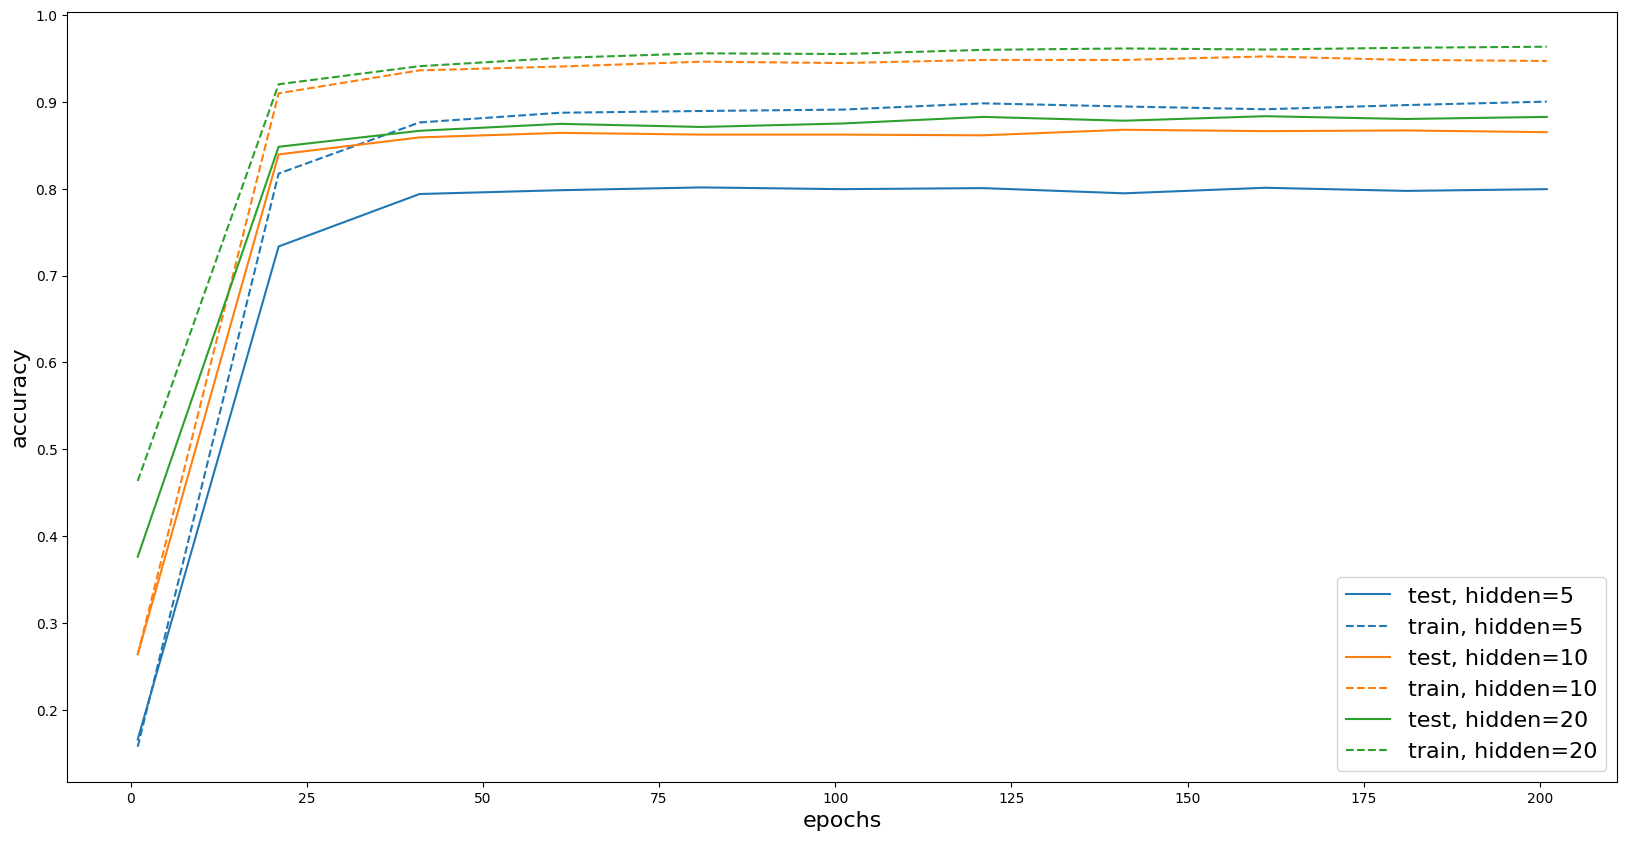

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,10))
epochs_array = [i for i in range(1, 220, 20)]

hidden_dims = [5, 10, 20]
colors = ['tab:blue', 'tab:orange', 'tab:green']

for nn, h, c in zip(nns, hidden_dims, colors):
    # solid = test, dashed = train, same color per hidden size
    ax.plot(epochs_array, nn.acc_test_array, color=c, label='test, hidden={}'.format(h))
    ax.plot(epochs_array, nn.acc_train_array, color=c, ls='dashed', label='train, hidden={}'.format(h))

ax.legend(loc="lower right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("accuracy", fontsize=16)
plt.show()

Give your explanation below.

The hidden layer dimension controls how much the network can represent. With more hidden units there are more weights, so the model can fit more complex decision boundaries.

In these runs the accuracy climbs steadily as the hidden size grows from 5 to 10 to 20, for both the training and the test sets (roughly: test accuracy around 0.81 at 5 units, 0.86 at 10, and 0.88 at 20). The 5-unit network is too small for 196-dimensional digit inputs and clearly underfits — it has the lowest accuracy on both curves. Going to 10 and then 20 units adds capacity and lifts both curves, with the gains getting smaller each time (diminishing returns).

The train curve always sits above the test curve, and that gap widens a bit as the hidden size grows — the extra capacity starts to memorize the training set, which is the beginning of overfitting. Here test accuracy still improves at 20 units, so we haven't gone too far, but if we kept increasing the hidden size (or dropped the small L2 term) we'd expect the test curve to flatten out or eventually dip while the train accuracy keeps rising.

## [14 points] Problem 4 - Tensors and Autograd
In this problem, we will demonstrate the benefits of PyTorch's Autograd mechanics by converting your implementation from Problem 3 to utilize PyTorch Tensors. This problem is not meant to be difficult, rather it should be quite simple once you've done Problem 3.

Note that there are other ways to go about this. We are keeping things as close to NumPy as possible on purpose. Take a moment to look through our modifications to get an understanding of the differences. In the comments, we'll make notes of native torch functions that perform the same operations.

Here, SGD is implemented manually to show you what's going on behind the scenes, but  usually you'd use [`torch.optim.SGD`](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD). For reference, the `weight_decay` parameter implements L2 normalization.

---

Before we move forward, let's cover a couple of points on notation.

Just as it's best practice to do `import numpy as np`, PyTorch has best practices for imports as well:

```python
import torch
import torch.nn as nn
import torch.nn.functional as F
```
You'll find that many of the functions you've been learning in NumPy have direct translations in PyTorch. The documentation can be found [here](https://pytorch.org/docs/stable/index.html) and is very user friendly, but we'll cover a few notable differences.

- The numpy parameter `axis` becomes `dim` in PyTorch.
- Tensors have [view](https://pytorch.org/docs/stable/tensor_view.html) operations, which avoid copying data unnecasarily. Use these instead of `reshape()`.
- Using `torch.from_numpy()` also avoids copying data stored in `numpy` arrays.
- Numpy interprets `np.dot()` of 2D matrices as matrix multiplication. Pytorch does not have this behaviour, see instead [`torch.matmul()`](https://pytorch.org/docs/stable/generated/torch.matmul.html?highlight=matmul#torch.matmul)
- PyTorch uses trailing underscores such as `torch.add_()` to denote in-place operations. As an example, the following operations are equivilent:
```python
x = x + y
x = torch.add(x, y)
x.add_(y)
```
You're likely to see these operations when randomly initializing Tensors, or filling a tensor with zeros:
```python
torch.nn.init.uniform_(x)
x.zero_()
```

---
Now onto the problem, your tasks are as follows:

1. Modify `forward_prop` to work on PyTorch Tensors.
2. Modify `SGD_step` to work on PyTorch Tensors. This is easier than it sounds, since with PyTorch we don't have to worry about calculating gradients manually.

In [12]:
import torch


class TorchNetwork(Network):
    def __init__(self, sizes, keep_prob=-1):
        super().__init__(sizes)
        
        # Convert your weights and biases to Tensors.
        # The flag requires_grad=True tells PyTorch to track gradients for us. 
        self.biases = [torch.tensor(b, requires_grad=True) for b in self.biases]
        self.weights = [torch.tensor(w, requires_grad=True) for w in self.weights]
        

    def g(self, z):
        """ Activation function
            Could also use torch.sigmoid(z)
        """
        return sigmoid_torch(z) 

    def forward_prop(self, a):
        """ Memory aware forward propagation. 
            Now this is for both training and testing.
        
        """
        # same as the numpy version, but np.dot -> torch.matmul
        for W, b in zip(self.weights, self.biases):
            a = self.g(torch.matmul(W, a) + b)
        return a

    def cost(self, a, y):
        """ Cost function, same as F.mse_loss()
        """
        return ((a - y)**2).mean() 
            

    def SGD_step(self, x, y, eta, lam):
        """
            Performs a single step of SGD on weights and biases

        Args:
            x: single sample features.
            y: single sample target.
            eta: learning rate.
            lam: Regularization parameter.
                
        """
        
        # Zero out the old gradients if they exist. 
        # Would be optim.zero_grad() if we were using an optimizer.
        for p in (*self.weights, *self.biases):
            if p.grad is not None:
                p.grad.detach_()
                p.grad.zero_()
            
        # forward, loss, then let autograd fill in every .grad for us
        a = self.forward_prop(x)
        loss = self.cost(a, y)
        loss.backward()

        # Perform sgd update 
        # Would be optimizer.step()
        with torch.no_grad():
            # l2 regularization on weights only.
            for p in self.weights:
                p.grad.add_(p, alpha=lam)
            # sgd update. 
            for p in (*self.weights, *self.biases):
                p.add_(p.grad, alpha=-eta)
                

def sigmoid_torch(z, threshold=20):
    """ Same as sigmoid before, now with torch.clamp() instead of np.clip().
        We could also just use torch.sigmoid().
    """
    z = torch.clamp(z, -threshold, threshold)
    return 1.0 / (1.0 + torch.exp(-z))


In [13]:
from tests import tests
tests.run_test_suite('new prob 4', TorchNetwork)
torch. __version__

TestBackPropWithoutRegularization (tests.tests.TestNetwork.TestBackPropWithoutRegularization) ... ok
TestBackPropWithRegularization (tests.tests.TestNetwork.TestBackPropWithRegularization) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.483s

OK


'2.5.1'

**Acknowledgment** : Chris Ketelsen, Chenhao Tan